## Кофе кофе кофееее

В современном мире кофе является ценной сельскохозяйственной культурой, которая высоко ценится и сильно полюбилась жителям многих стран!
В этом проекте я буду рассматривать экономическую динамику кофе, а именно его производства и потребления, экспорта и импорта (с 1990 по 2020).

Данные для проекта были взяты с сайта Международной организации по кофе *(International Coffee Organization)* https://ico.org/

Уверена, что инструменты и возможности `python` позволят получить ценную для анализа статистику!





Для начала конечно же загрузим файлы формата `csv` с помощью модуля `pandas` в `python`:

In [399]:
import   pandas as pd
import matplotlib.pyplot as plt
data_prod = pd.read_csv('Coffee_production.csv')
data_import = pd.read_csv('Coffee_import.csv')
data_ic = pd.read_csv('Coffee_importers_consumption.csv')

prod = pd.DataFrame(data_prod)
prod.head()

,Country,Coffee type,1990/91,1991/92,1992/93,1993/94,1994/95,1995/96,1996/97,1997/98,...,2011/12,2012/13,2013/14,2014/15,2015/16,2016/17,2017/18,2018/19,2019/20,Total_production
0,Angola,Robusta/Arabica,3.000000e+06,4.740000e+06,4.680000e+06,1.980000e+06,4.620000e+06,3.720000e+06,4.260000e+06,3.840000e+06,...,1.740000e+06,1.980000e+06,2.100000e+06,2.340000e+06,2.460000e+06,2.700000e+06,2.100000e+06,2.520000e+06,3.120000e+06,8.208000e+07
1,Bolivia (Plurinational State of),Arabica,7.380000e+06,6.240000e+06,7.200000e+06,3.060000e+06,7.020000e+06,8.520000e+06,7.500000e+06,8.460000e+06,...,7.920000e+06,6.300000e+06,7.200000e+06,6.000000e+06,5.040000e+06,4.680000e+06,5.040000e+06,4.980000e+06,4.860000e+06,2.070000e+08
2,Brazil,Arabica/Robusta,1.637160e+09,1.637580e+09,2.076180e+09,1.690020e+09,1.691520e+09,1.083600e+09,1.751820e+09,1.568880e+09,...,2.915520e+09,3.325080e+09,3.281340e+09,3.198300e+09,3.172260e+09,3.407280e+09,3.164400e+09,3.907860e+09,3.492660e+09,7.508298e+10
3,Burundi,Arabica/Robusta,2.922000e+07,4.002000e+07,3.720000e+07,2.358000e+07,3.984000e+07,2.604000e+07,2.406000e+07,1.500000e+07,...,1.224000e+07,2.436000e+07,9.780000e+06,1.488000e+07,1.614000e+07,1.176000e+07,1.212000e+07,1.224000e+07,1.632000e+07,6.236400e+08
4,Ecuador,Arabica/Robusta,9.024000e+07,1.274400e+08,7.110000e+07,1.241400e+08,1.425600e+08,1.132800e+08,1.195800e+08,7.146000e+07,...,4.950000e+07,4.968000e+07,3.996000e+07,3.864000e+07,3.864000e+07,3.870000e+07,3.744000e+07,2.976000e+07,3.354000e+07,1.900380e+09


## Динамика производства, лидеры рынка...

Посмотрим на общую динамику производства кофе в мире с 1990 по 2020:

In [344]:
prod.loc[55] = prod.sum(axis=0)
prod_list1 = prod.iloc[55, 2:-1].tolist()
prod_list2 = prod.columns[2:-1].tolist()

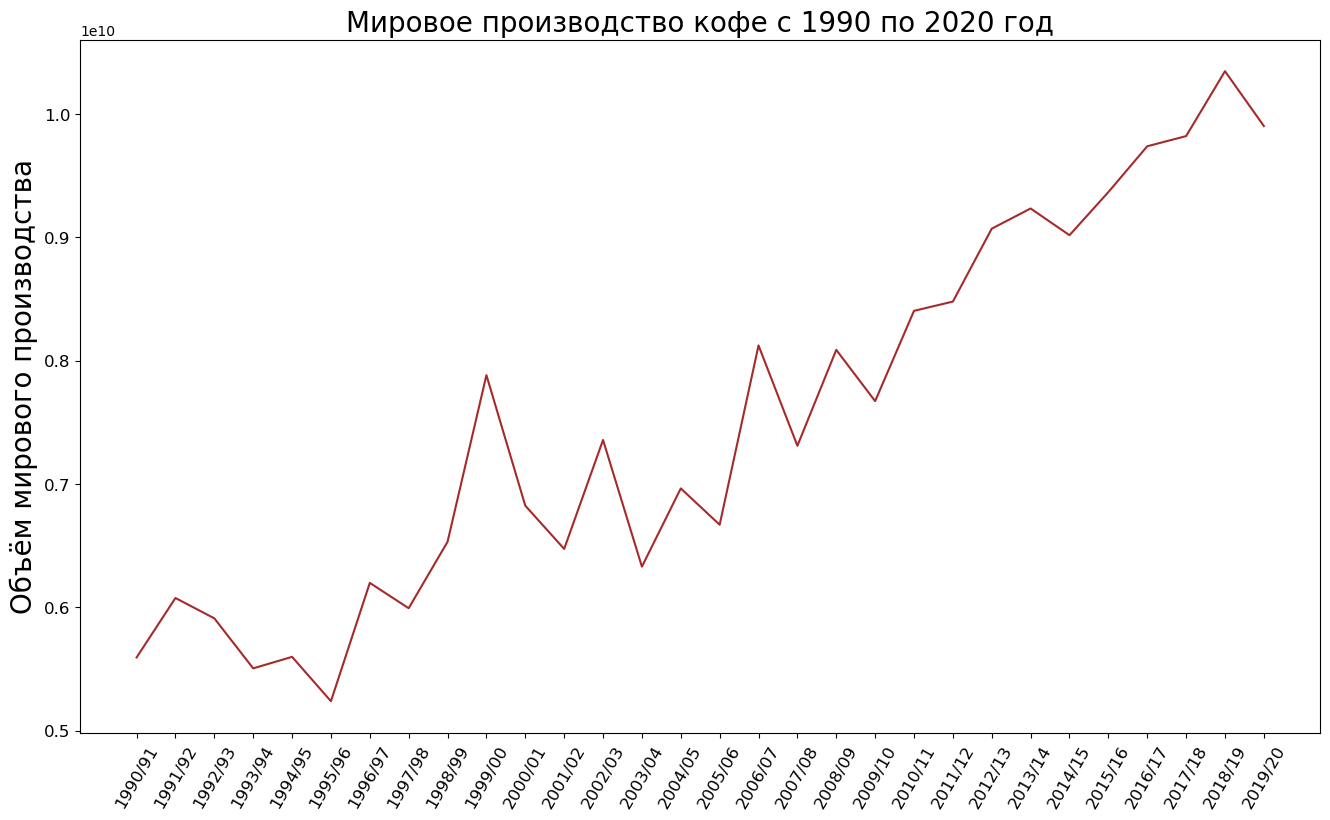

In [346]:
plt.figure(figsize=(16,9))
plt.plot(prod_list2, prod_list1, color='brown')
plt.title('Мировое производство кофе с 1990 по 2020 год', fontsize=20)
plt.xticks(rotation=60)
plt.ylabel('Объём мирового производства', fontsize=20)
plt.gca().tick_params(labelsize=12)

Рост мирового производства очень нестабильный, но при этом значительный (особенно с 2009 года)

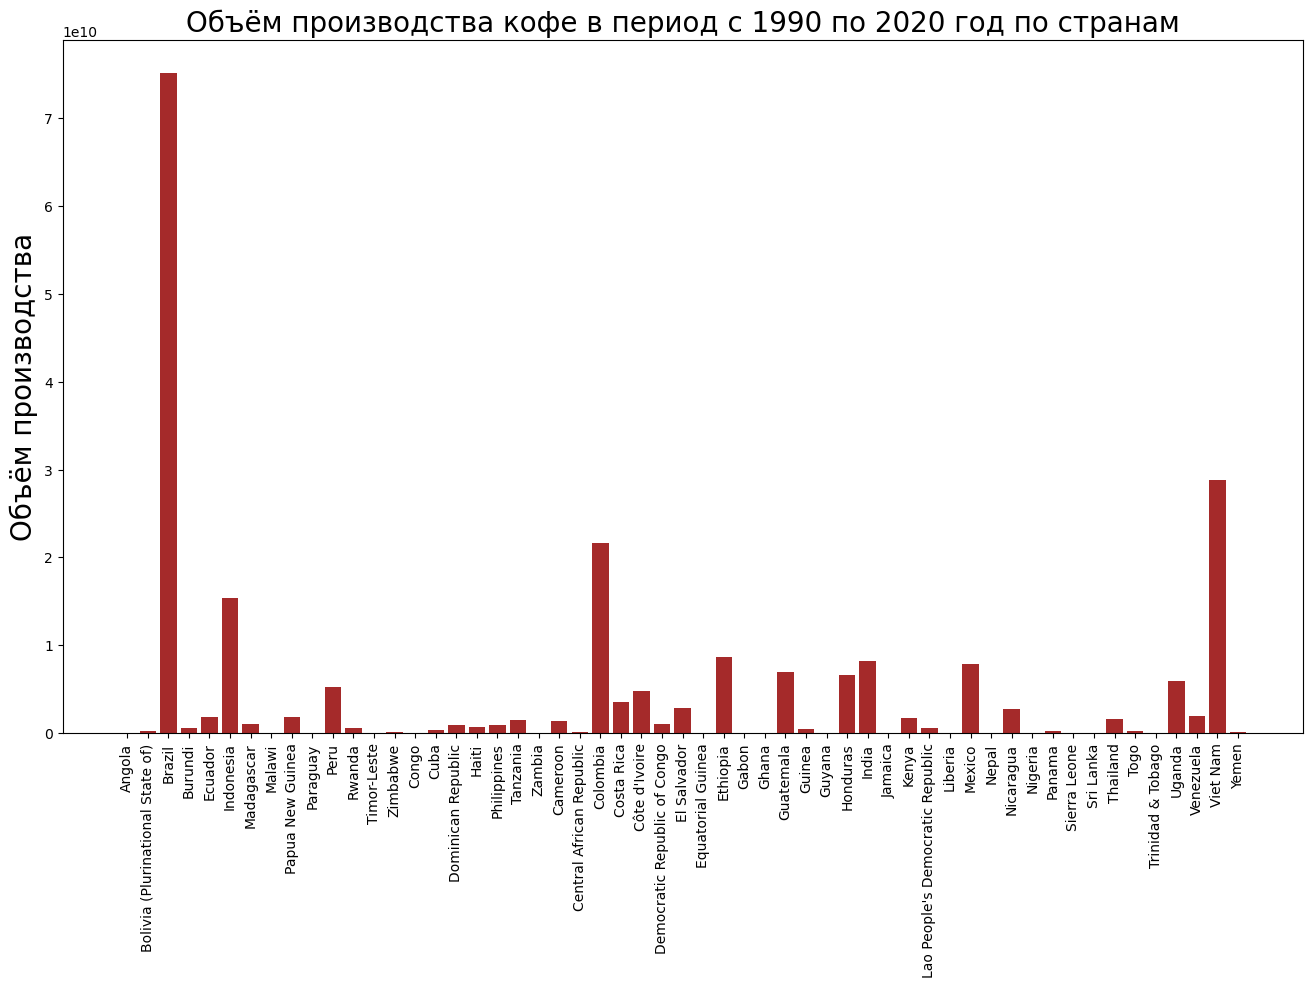

In [308]:
prod_list1 = prod.iloc[0:, -1].tolist()
prod_list2 = prod['Country']
plt.figure(figsize=(16,9))
plt.bar(prod_list2, prod_list1, color='brown')
plt.title('Объём производства кофе в период с 1990 по 2020 год по странам', fontsize=20)
plt.ylabel('Объём производства', fontsize=20)
plt.xticks(rotation=90)
plt.gca().tick_params(labelsize=10)

Тааааак, кажется здесь есть ярковыраженные **лидеры производства**... Теперь выделим их:

In [247]:
prod_leaders = prod.sort_values(by = 'Total_production', ascending=False).head(4)
prod_leaders

,Country,Coffee type,1990/91,1991/92,1992/93,1993/94,1994/95,1995/96,1996/97,1997/98,...,2011/12,2012/13,2013/14,2014/15,2015/16,2016/17,2017/18,2018/19,2019/20,Total_production
2,Brazil,Arabica/Robusta,1.637160e+09,1.637580e+09,2.076180e+09,1.690020e+09,1.691520e+09,1.083600e+09,1.751820e+09,1.568880e+09,...,2.915520e+09,3.325080e+09,3.281340e+09,3.198300e+09,3.172260e+09,3.407280e+09,3.164400e+09,3.907860e+09,3.492660e+09,7.508298e+10
53,Viet Nam,Robusta/Arabica,7.860000e+07,8.628000e+07,1.404000e+08,1.812000e+08,2.179200e+08,2.382000e+08,3.451200e+08,4.187400e+08,...,1.590000e+09,1.404120e+09,1.656600e+09,1.634460e+09,1.865400e+09,1.669140e+09,2.005920e+09,1.816980e+09,1.829220e+09,2.880318e+10
23,Colombia,Arabica,8.637600e+08,1.078800e+09,8.968200e+08,6.853200e+08,7.778400e+08,7.762800e+08,6.467400e+08,7.273200e+08,...,4.591800e+08,5.956200e+08,7.274400e+08,7.999800e+08,8.405400e+08,8.780400e+08,8.294400e+08,8.319600e+08,8.460000e+08,2.159862e+10
5,Indonesia,Robusta/Arabica,4.464600e+08,5.095800e+08,3.341400e+08,4.045800e+08,3.220800e+08,2.743800e+08,4.932600e+08,4.572600e+08,...,4.133400e+08,7.842000e+08,7.740600e+08,6.567600e+08,7.551000e+08,6.924600e+08,6.511200e+08,5.770800e+08,6.859800e+08,1.540488e+10


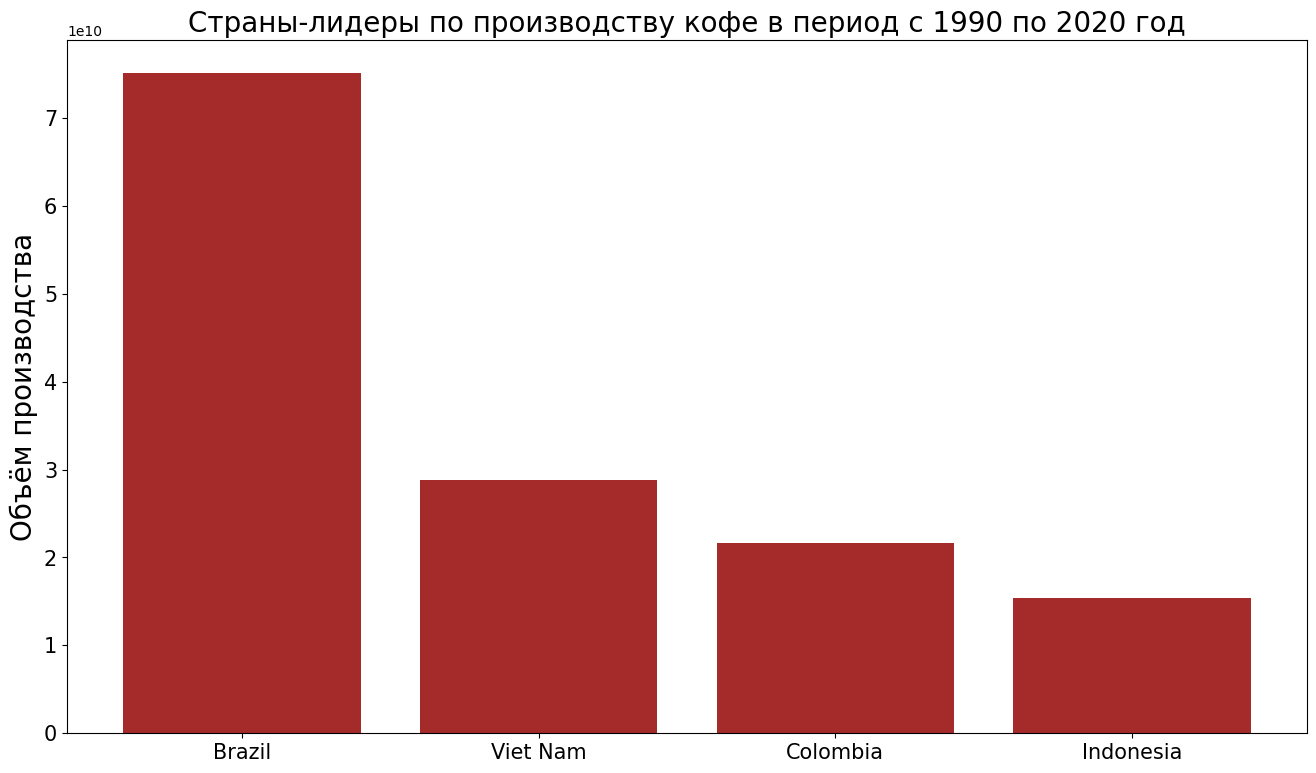

In [310]:
plt.figure(figsize=(16,9))
plt.bar(prod_leaders['Country'], prod_leaders['Total_production'], color='brown')
plt.title('Cтраны-лидеры по производству кофе в период с 1990 по 2020 год', fontsize=20)
plt.ylabel('Объём производства', fontsize=20)
plt.gca().tick_params(labelsize=15)

## Динамика импорта...

Теперь посмотрим на динамику импорта кофе - какие страны являются главными импортёрами??

In [349]:
importers = pd.DataFrame(data_import)
importers.head()

,Country,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,Total_import
0,Austria,112800000,123480000,132360000,110160000,85020000,73860000,72600000,77640000,77580000,...,87120000,93540000,93300000,91500000,90780000,89700000,87600000,85740000,86880000,2765760000
1,Belgium,0,0,0,0,0,0,0,0,0,...,349680000,340080000,330120000,312720000,332040000,363120000,340620000,344520000,371940000,6240540000
2,Belgium/Luxembourg,120900000,104760000,109680000,123780000,135720000,144060000,151560000,152640000,214800000,...,0,0,0,0,0,0,0,0,0,1257900000
3,Bulgaria,16080000,12000000,10920000,23820000,27780000,30900000,16320000,17640000,20520000,...,28920000,33600000,36540000,37260000,40920000,46740000,42420000,44220000,47100000,830700000
4,Croatia,0,0,10080000,9780000,11580000,19200000,19320000,23100000,20340000,...,23460000,23040000,24780000,25200000,26220000,28740000,26340000,26760000,27960000,622080000


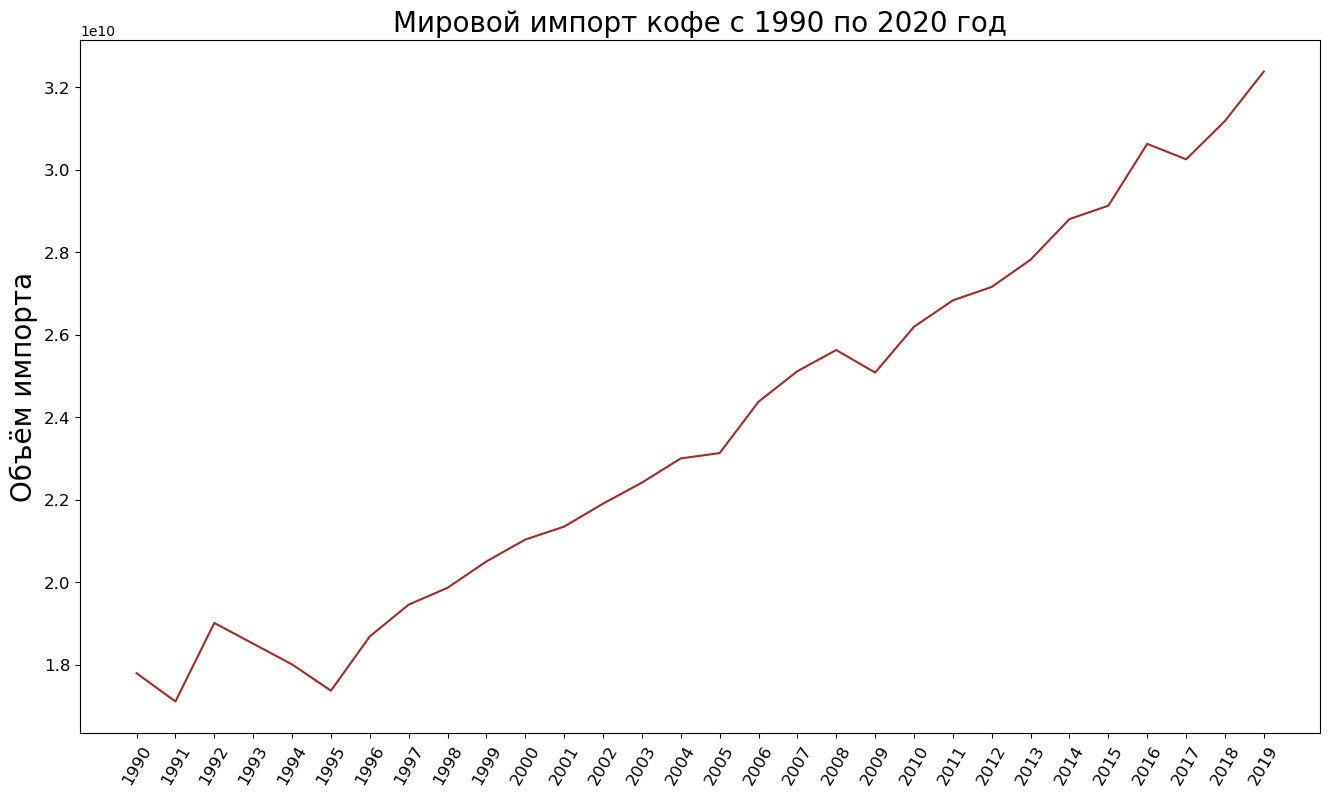

In [340]:
importers.loc[35] = importers.sum(axis=0)
years = importers.columns[1:-1].tolist()
imp_list1 = importers.iloc[35, 1:-1].tolist()
plt.figure(figsize=(16,9))
plt.plot(years, imp_list1, color='brown')
plt.title('Мировой импорт кофе с 1990 по 2020 год', fontsize=20)
plt.xticks(rotation=60)
plt.ylabel('Объём импорта', fontsize=20)
plt.gca().tick_params(labelsize=12)

Интересно, что пока производство кофе испытывало значительные колебания в рассматриваемые 30 лет (скорее всего связанные с урожайностью, кризисами в странах-производителях), мировой импорт стабильно рос, начиная **с 1955 года**

In [ ]:
importers = pd.DataFrame(data_import)
importers.head()

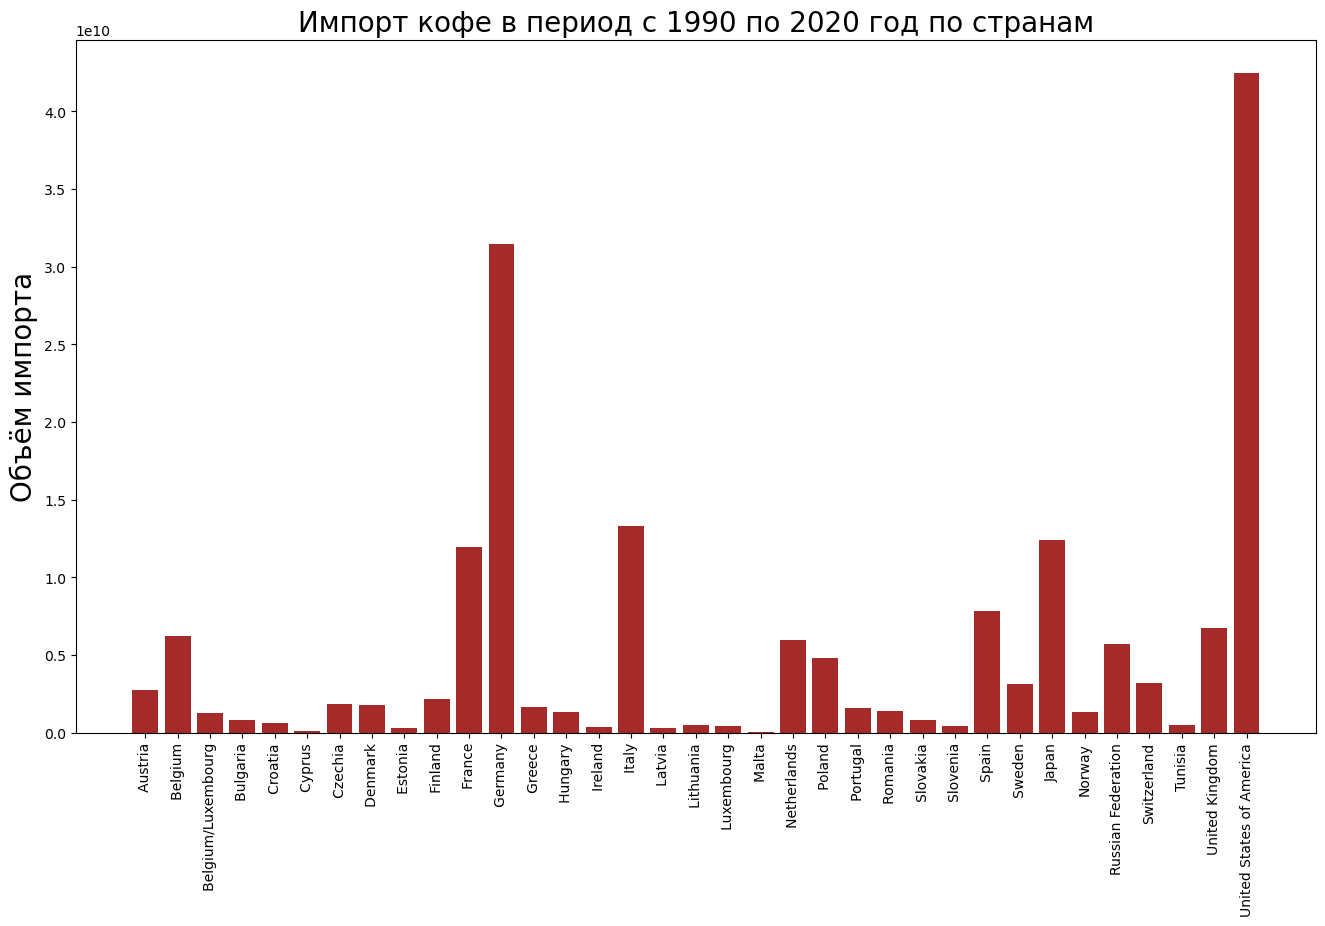

In [312]:
imp_list1 = importers['Total_import'].tolist()
imp_list2 = importers['Country'].tolist()
plt.figure(figsize=(16,9))
plt.bar(imp_list2, imp_list1, color='brown')
plt.title('Импорт кофе в период с 1990 по 2020 год по странам', fontsize=20)
plt.ylabel('Объём импорта', fontsize=20)
plt.xticks(rotation=90)
plt.gca().tick_params(labelsize=10)

In [243]:
import_leaders = importers.sort_values(by = 'Total_import', ascending=False).head()
import_leaders

,Country,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,Total_import
34,United States of America,1260420000,1190400000,1376340000,1159740000,970260000,1026420000,1166700000,1220580000,1261800000,...,1565580000,1563360000,1620960000,1653900000,1662480000,1730280000,1769280000,1735080000,1851240000,42507660000
11,Germany,820260000,793740000,827340000,846420000,814980000,771120000,810420000,834300000,824400000,...,1255560000,1308960000,1270440000,1324680000,1278960000,1342080000,1305900000,1328820000,1345920000,31481400000
15,Italy,314520000,277800000,275700000,335640000,333240000,323280000,336480000,344580000,353340000,...,501300000,521460000,529380000,561000000,559680000,613440000,601200000,638340000,654840000,13272120000
28,Japan,319800000,330600000,319560000,341460000,373020000,329340000,359640000,355260000,361620000,...,452640000,421500000,502860000,459420000,483780000,481560000,458820000,452400000,482400000,12422760000
10,France,378060000,393180000,396720000,380040000,382140000,372840000,399600000,402240000,394560000,...,419520000,410460000,402780000,426720000,408540000,404280000,418020000,457440000,479580000,11972520000


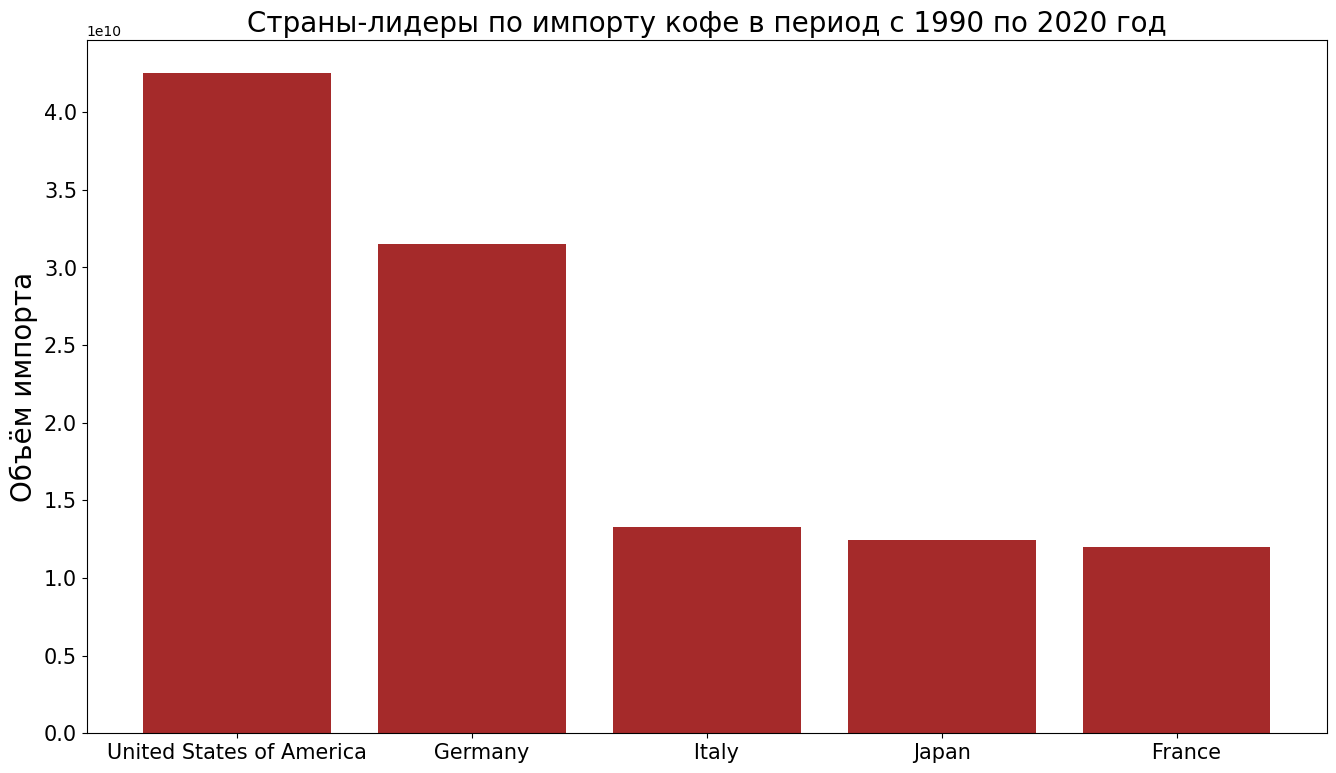

In [314]:
plt.figure(figsize=(16,9))
plt.bar(import_leaders['Country'], import_leaders['Total_import'], color='brown')
plt.title('Страны-лидеры по импорту кофе в период с 1990 по 2020 год', fontsize=20)
plt.ylabel('Объём импорта', fontsize=20)
plt.gca().tick_params(labelsize=15)

Довольно логично, пятёрка лидеров представляет собой пятёрку наиболее развитых стран (ну за исключением Великобритании, у которой *5 o'clock tea*)

## Главные кофеманы

Теперь посмотрим на статистку потребления кофе - за период в целом, и по отдельным странам!

In [387]:
ic = pd.DataFrame(data_ic)
ic.head()

,Country,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,Total_import_consumption
0,Austria,80400000,78120000,72720000,80100000,65160000,60720000,64560000,65220000,66300000,...,67020000,76140000,74940000,68100000,68160000,71580000,69720000,70320000,70380000,1904520000
1,Belgium,0,0,0,0,0,0,0,0,0,...,56040000,54900000,74700000,75540000,64440000,90120000,78000000,81900000,71100000,1460520000
2,Belgium/Luxembourg,67440000,42480000,41760000,47340000,57480000,64380000,62340000,53160000,78540000,...,0,0,0,0,0,0,0,0,0,514920000
3,Bulgaria,6120000,1020000,10500000,19620000,21180000,23580000,14760000,16500000,19440000,...,21600000,22560000,25140000,22560000,24360000,27120000,24900000,25560000,25380000,625080000
4,Croatia,0,0,8100000,7920000,9840000,17280000,18240000,21660000,19200000,...,22020000,21600000,23220000,22080000,22500000,22800000,21660000,21600000,22860000,564180000


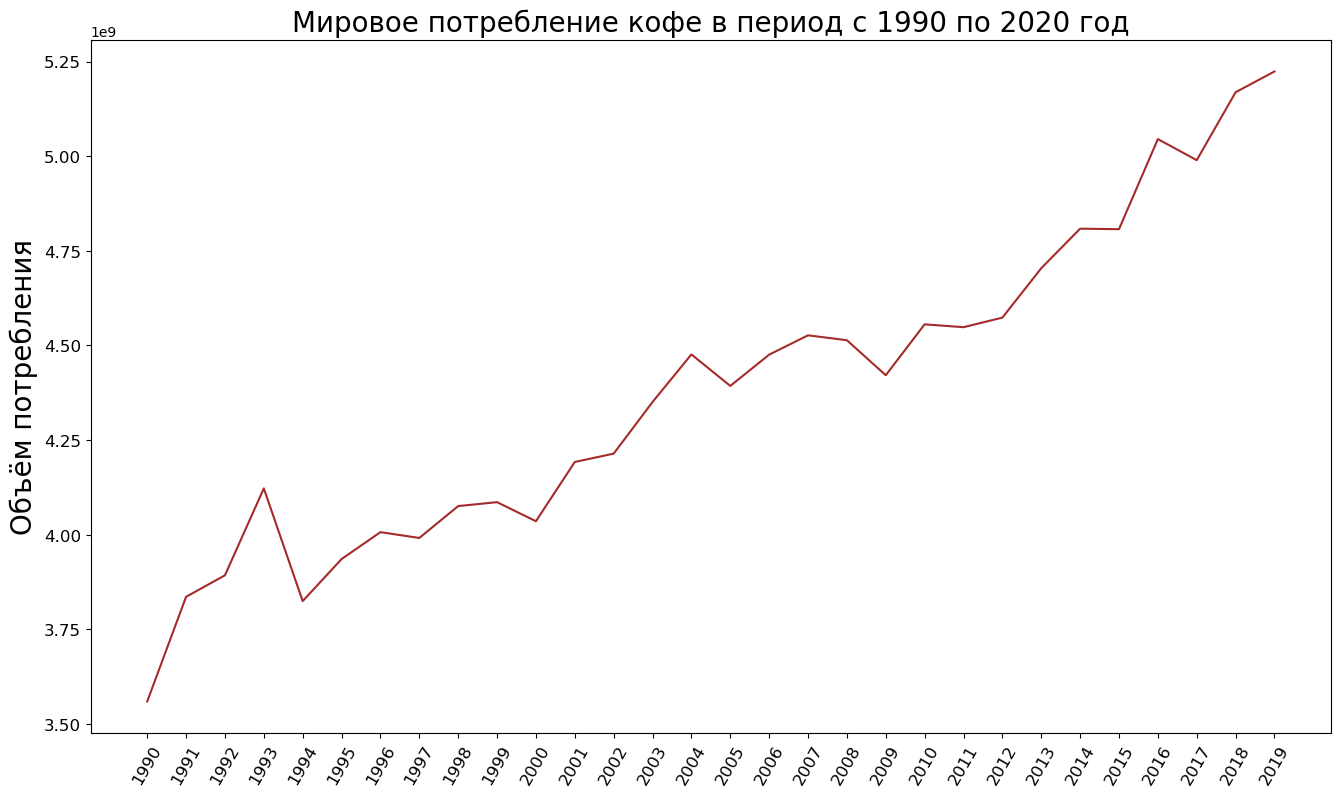

In [361]:
ic.loc[35] = ic.sum(axis=0)
years = ic.columns[1:-1].tolist()
con_list1 = ic.iloc[35, 1:-1].tolist()
plt.figure(figsize=(16,9))
plt.plot(years, con_list1, color='brown')
plt.title('Мировое потребление кофе в период с 1990 по 2020 год', fontsize=20)
plt.xticks(rotation=60)
plt.ylabel('Объём потребления', fontsize=20)
plt.gca().tick_params(labelsize=12)

*Кажется популярность айс-латте сделала своё дело...*

Конечно же дело не в этом, но визуализация подтверждает тезис о том, что **популярность кофе увеличивается** (активный рост потребления с 2009 года)

In [ ]:
ic = pd.DataFrame(data_ic)
ic.head()

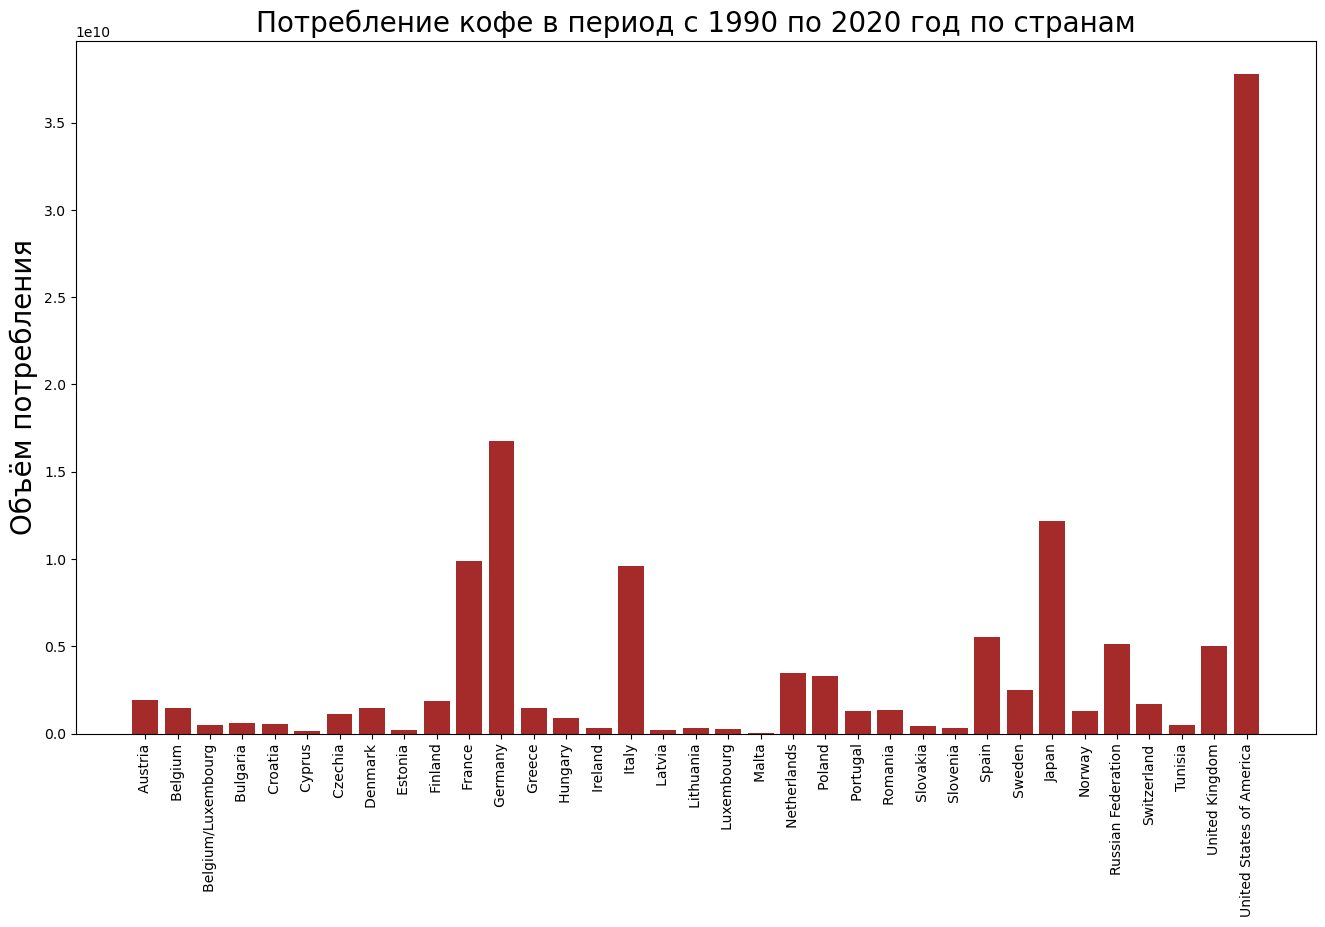

In [366]:
con_list1 = ic['Total_import_consumption'].tolist()
con_list2 = ic['Country'].tolist()
plt.figure(figsize=(16,9))
plt.bar(con_list2, con_list1, color='brown')
plt.title('Потребление кофе в период с 1990 по 2020 год по странам', fontsize=20)
plt.ylabel('Объём потребления', fontsize=20)
plt.xticks(rotation=90)
plt.gca().tick_params(labelsize=10)

Картина идентичная, наши главные потребители капучино это...

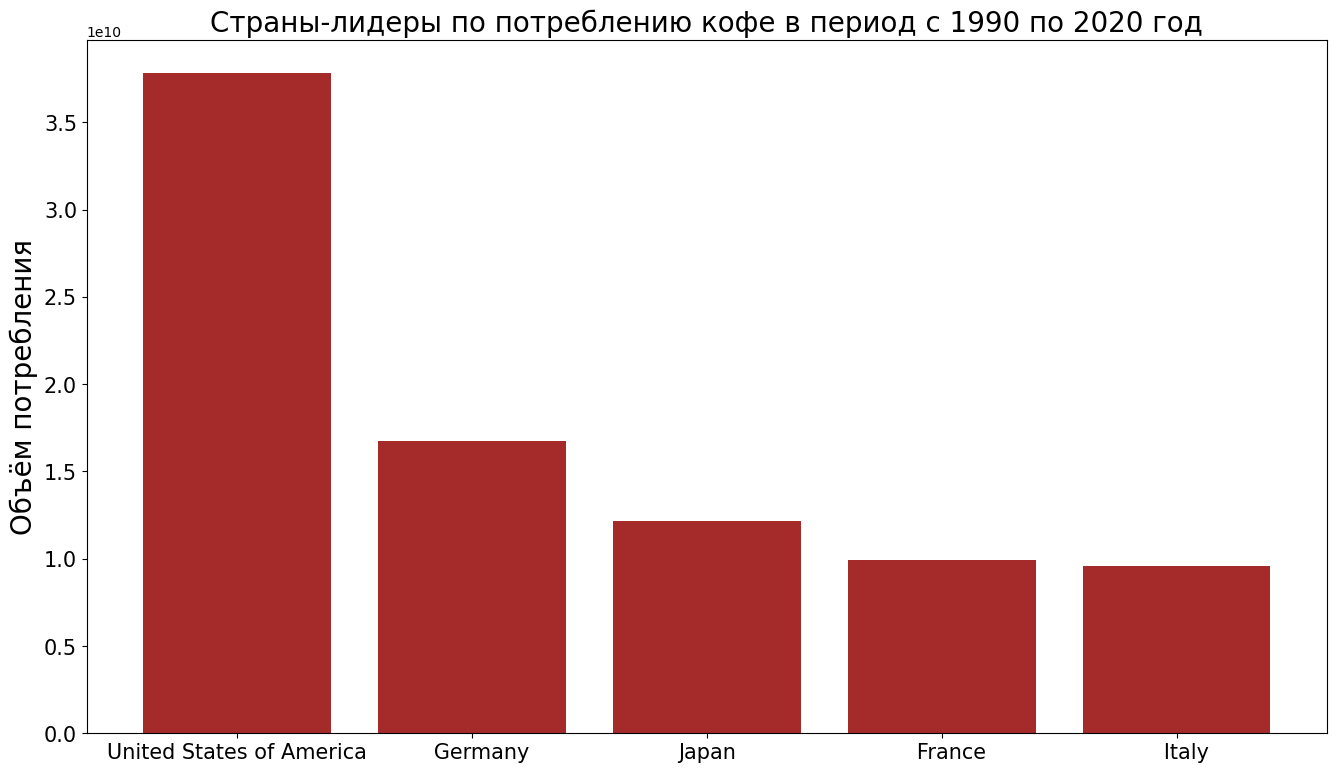

In [369]:
con_leaders = ic.sort_values(by = 'Total_import_consumption', ascending=False).head()
con_leaders
plt.figure(figsize=(16,9))
plt.bar(con_leaders['Country'], con_leaders['Total_import_consumption'], color='brown')
plt.title('Страны-лидеры по потреблению кофе в период с 1990 по 2020 год', fontsize=20)
plt.ylabel('Объём потребления', fontsize=20)
plt.gca().tick_params(labelsize=15)

## А что в России?

Ну и конечно мы не можем не обратить внимание на статистику по РФ, так как рост количества кофеен в геометрической прогрессии заметен уж точно не мне одной...

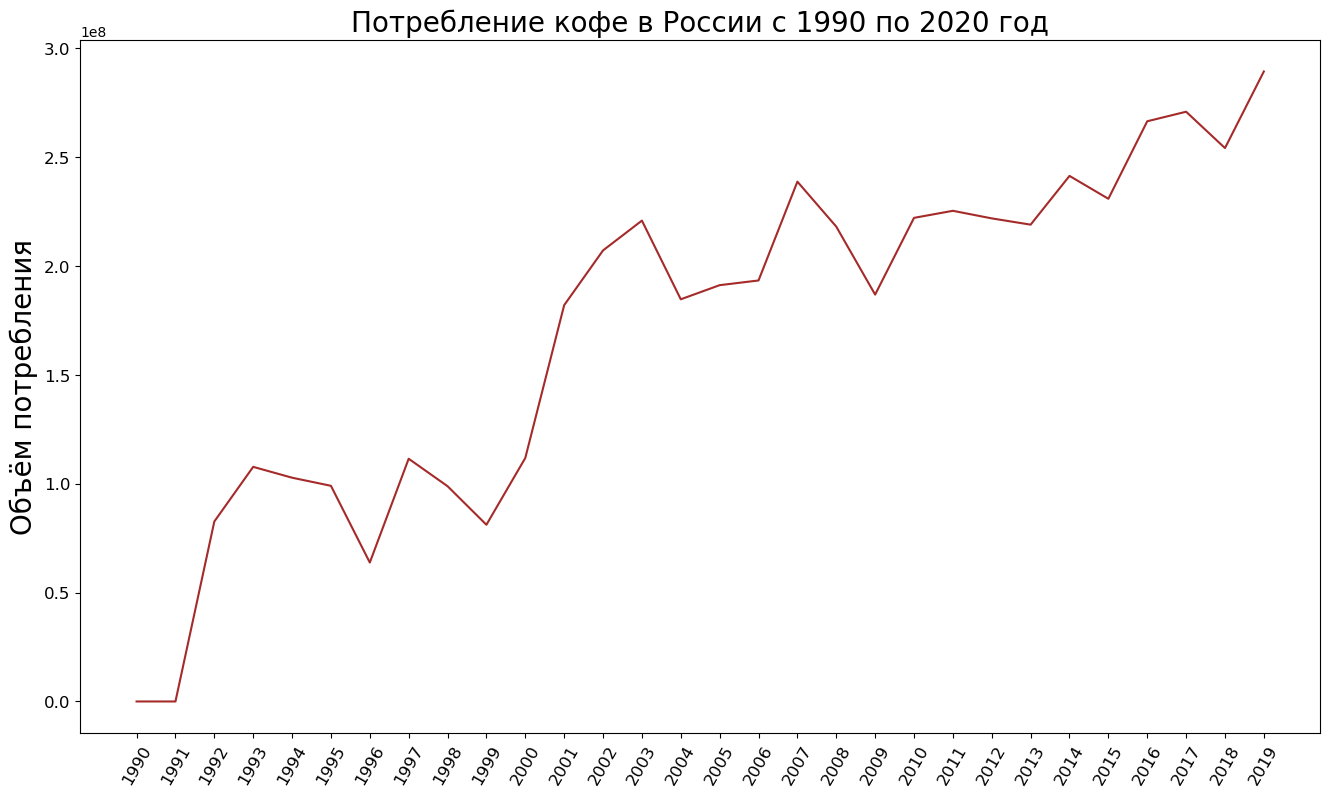

In [377]:
years = ic.columns[1:-1].tolist()
rus_list = ic.iloc[30, 1:-1].tolist()
plt.figure(figsize=(16,9))
plt.plot(years, rus_list, color='brown')
plt.title('Потребление кофе в России с 1990 по 2020 год', fontsize=20)
plt.xticks(rotation=60)
plt.ylabel('Объём потребления', fontsize=20)
plt.gca().tick_params(labelsize=12)

Даааа, хоть Россия и не входит в лидеры по импорту и потреблению кофе, да и объём потребления очень не стабильный, тем не менее в последние годы он идёт на подъём

Чтобы оценить масштаб проблемы, визуализируем на одном графике статистику **по России и по США** (лидер импорта и потребления)

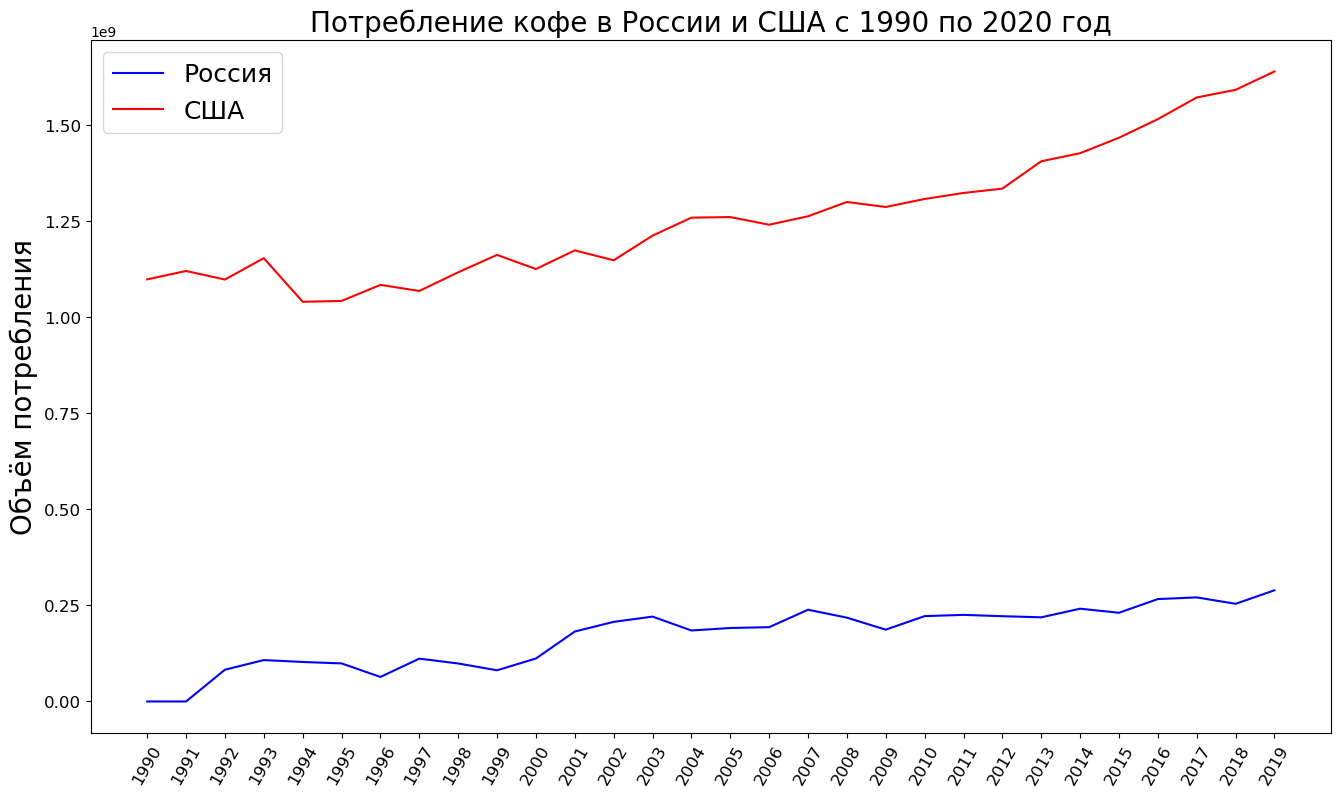

In [384]:
plt.figure(figsize=(16,9))
plt.plot(years, rus_list, color='blue')
usa_list = ic.iloc[34, 1:-1].tolist()
plt.plot(years, usa_list, color='red')
plt.title('Потребление кофе в России и США с 1990 по 2020 год', fontsize=20)
plt.xticks(rotation=60)
plt.ylabel('Объём потребления', fontsize=20)
plt.gca().tick_params(labelsize=12)
plt.legend(['Россия', 'США'], fontsize=18)

С помощью визуализации мы можем увидеть, как сильно **потребление в России отстаёт от США** (и по количеству, и по темпам роста)

## Выводы, рефлексия, глубокие мысли...

Итак, пришло время подвести итоги моего исследования!

С помощью датасета и модулей `pandas` и `matplotlib.pyplot` я смогла визуализировать динамику производства, импорта и потребления кофе в период с 1990 по 2020 год. Как для всего мира, так и по отдельным странам.

Наиболее значимые тезисы:
1. Не очень стабильный (кризисы, неурожай), но значительный рост производства кофе
2. Основные производители: **Бразилия, Вьетнам, Колумбия, Индонезия**
3. Стабильный рост импорта и потребления с 1995 года по 2020
4. Лидеры по импорту и потреблению: **США, Германия, Япония, Франция, Италия**
5. В России потребление кофе испытывает значительные колебания, но общая тенденция на увеличение
6. По сравнению с США, в России незначительный рост и объём потребления

Спасибо, что дочитали до конца! **Желаю вам самого вкусного капучино/айс-латте/эспрессо!!!**